In [1]:
"""
Data Assimilation Preprocessing

Workflow
1. Station data
    1a. load_station_meta(): 
        Reads the station metadata CSV and joins with per-station data files 
        to bring in elevation, latitude, longitude, and timezone for each station ID.
    1b. load_station_timeseries(): 
        Reads individual station CSVs, converts timestamps from local timezones to UTC,
        and standardizes the column structure across stations (temp_air, temp_dew, RH).
    1c. hourly_station_agg(): 
        Collapses all station data to the hourly level — at each hour, averages all 
        observations within that hour for each station. This produces one row per station-hour.
    1d. lapse_adjusted_idw_fill(): 
        After aggregation, fills missing hourly station temperature values using an 
        altitude-corrected 2D IDW approach that mirrors RainOrSnowTools::model_meteo():
            • Estimate a dynamic lapse rate (°C/m) from available stations at each hour 
              via regression of temperature vs elevation; fall back to a static lapse (-0.0065 K/m) if unstable.
            • Normalize station temperatures to a reference elevation 
              (typically the median of available station elevations).
            • Perform 2D IDW interpolation on the normalized values in a projected CRS.
            • De-normalize the interpolated values back to each station's elevation.
        This produces a physically consistent, vertically adjusted infill for missing temperatures.
    1e. fill_station_row_vars(): 
        Recomputes dependent meteorological variables for all hourly station records:
            • Dewpoint (Td) from temperature (Ta) and relative humidity (RH)
            • Relative humidity (RH) from Ta and Td when missing
            • Wet-bulb temperature (Tw) using Stull (2011), with a psychrometric fallback
        Ensures all hourly station predictors (Ta, Td, RH, Tw) are mutually consistent.

2. IMERG: 
    2a. Converts wide parquet files to long format, parses timestamps, 
        and averages the two 30-minute IMERG products within each hour to produce hourly mean PLP (%) values.
    2b. Appends DEM elevation to each IMERG grid coordinate for later use in modeling.

3. MRoS: 
    3a. Aggregates MRoS (crowdsourced precipitation-phase) observations to the hourly level.
        If multiple observations occur from the same observer within the hour, 
        retains only the latest record (assuming a correction to earlier input).
    3b. Converts categorical phase ("snow" / "mix" / "rain") to numeric proxy values 
        (0 = snow, 50 = mix, 100 = rain) and appends DEM elevation at each point.

4. Final harmonization: 
    By this stage, all datasets (stations, IMERG, MRoS) share consistent columns:
        • lat, lon, elev
        • datetime_utc (floored to hour)
        • predictor variables (e.g., temp_air, rh, plp, mros_plp_proxy)
    Each dataset is filtered spatially to the DEM AOI boundary before export.
"""


import re
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
import rasterio as rio
from rasterio.warp import transform_bounds, reproject, Resampling, calculate_default_transform
from pyproj import CRS, Transformer
import pytz
from sklearn.linear_model import LinearRegression
import math
from scipy.spatial import cKDTree



# Path setups

In [17]:
# --------------------------- CONFIG ---------------------------------
BASE_DIR = Path().resolve().parent  # current working dir
print("BASE_DIR:", BASE_DIR)


CONFIG = {
    "wy_start": "2024-10-01T00:00:00Z",
    "wy_end":   "2025-05-31T23:59:59Z",
    # "test_start": "2025-02-01T00:00:00Z",   # narrow test window first
    # "test_end":   "2025-04-01T00:00:00Z",
    "test_start": "2024-10-01T00:00:00Z",   # Entire window
    "test_end":   "2025-05-31T23:59:59Z",

    "station_meta_csv": BASE_DIR / "Data/Stations/station_metadata_20241001_20250531.csv",
    "station_dir": BASE_DIR / "Data/Stations",   # per-station CSVs, temp data is already converted to Celcius via preprocess_meteo() from rainorsnowtools
    "imerg_dir":   BASE_DIR / "Data/IMERG",      # parquet (wide)
    "mros_parquet": BASE_DIR / "Data/observations/wy25_mros_obs.parquet",

    "dem_path": "C:/Users/EmmaGolub/Desktop/MRoS_local/local_data/DEM_AOI_TNM_10m.tif",
    "dem_path_km": BASE_DIR / "DEM_1km.tif",
    "dem_path_km_clipped": BASE_DIR / "DEM_1km_clipped_v2.tif",
    "out_dir":  BASE_DIR / "outputs/hourly_pipeline",
}

out_dir = Path(CONFIG["out_dir"])
out_dir.mkdir(parents=True, exist_ok=True)

BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype


# Utility Functions

In [3]:
# ------------------------- UTIL: time --------------------------------
def to_utc(dt_series: pd.Series) -> pd.DatetimeIndex:
    """Force timestamps to UTC, making naive → UTC-naive assumed in UTC."""
    dt = pd.to_datetime(dt_series, errors="coerce", utc=True)
    # If dt_series had naive datetimes and pandas assumed local, .tz_convert('UTC') not needed.
    return dt

def hourly_index(start_iso: str, end_iso: str) -> pd.DatetimeIndex:
    return pd.date_range(start=pd.to_datetime(start_iso), end=pd.to_datetime(end_iso),
                         freq="H", tz="UTC")

def print_time(ts):
    return pd.to_datetime(ts).strftime("%Y-%m-%d %H:%MZ")

In [5]:
# ---------------------- UTIL: meteorology functions -------------------------

# Magnus (Tetens) saturation vapor pressure over water (°C)
#  How much moisture air can hold at saturation
def esat_hpa(Tc: float) -> float:
    return 6.112 * np.exp(17.27 * Tc / (Tc + 237.3))

# Dew point temperature from air temperature and relatuve humidity
#  Essentially rearranges Magnus equation.
def td_from_ta_rh(TaC: np.ndarray, RH: np.ndarray) -> np.ndarray:
    """Dewpoint from air temp (°C) and RH (%)"""
    TaC = np.asarray(TaC, dtype=float)
    RH = np.clip(np.asarray(RH, dtype=float), 1e-6, 100.0)
    a, b = 17.27, 237.3
    gamma = np.log(RH / 100.0) + (a * TaC) / (b + TaC)
    Td = (b * gamma) / (a - gamma)
    return Td

# Relative humidity from air temperature and dewpoint
#  (Inverse of dew point calculation)
def rh_from_ta_td(TaC: np.ndarray, TdC: np.ndarray) -> np.ndarray:
    """RH (%) from air temp and dewpoint (°C)"""
    TaC = np.asarray(TaC, dtype=float)
    TdC = np.asarray(TdC, dtype=float)
    a, b = 17.27, 237.3
    ln_es_Ta = (a * TaC) / (b + TaC)
    ln_es_Td = (a * TdC) / (b + TdC)
    RH = 100.0 * np.exp(ln_es_Td - ln_es_Ta)
    return np.clip(RH, 0.0, 100.0)

# Approximates wet-bulb temperature using Stull's (2011) empirical formula
#  Reflects evaporative cooling (snow vs rain)
def tw_stull(TaC: np.ndarray, RH: np.ndarray) -> np.ndarray:
    """
    Wet-bulb approximation (°C) by Stull (2011).
    TaC in °C, RH in %
    """
    TaC = np.asarray(TaC, dtype=float)
    RH = np.clip(np.asarray(RH, dtype=float), 1e-6, 100.0)
    Tw = (TaC * np.arctan(0.151977 * np.sqrt(RH + 8.313659)) +
          np.arctan(TaC + RH) - np.arctan(RH - 1.676331) +
          0.00391838 * RH**1.5 * np.arctan(0.023101 * RH) - 4.686035)
    return Tw


# --- Supplementary meteorology functions ---
def psychrometric_tw(TaC: float, RH: float, P_hPa: float = 1013.25) -> float:
    """
    Psychrometric wet bulb temperature (°C).
    Iterative solution of energy balance.
    TaC : air temp in °C
    RH  : relative humidity in %
    P_hPa : pressure in hPa (default sea level)
    """
    TaC = float(TaC)
    RH = float(RH)
    if not math.isfinite(TaC) or not math.isfinite(RH):
        return np.nan
    # Actual vapor pressure (hPa)
    ea = (RH / 100.0) * esat_hpa(TaC)
    # Psychrometric constant (hPa/°C)
    cp = 1004.0        # J/kg/K
    Lv = 2.5e6         # J/kg
    epsilon = 0.622    # ratio of molecular weights
    gamma = cp * P_hPa / (Lv * epsilon) / 100.0  # hPa/°C
    # Iterative solve
    Tw = TaC
    for _ in range(50):
        es_tw = esat_hpa(Tw)
        rhs = (TaC - Tw) * gamma
        lhs = es_tw - ea
        Tw_new = Tw + 0.2 * (rhs - lhs)  # relaxation step
        if abs(Tw_new - Tw) < 0.01:
            break
        Tw = Tw_new
    return Tw

def fill_station_row_vars(df: pd.DataFrame) -> pd.DataFrame:
    """
    Fill missing dewpoint, RH, and wet-bulb for each row.
    Uses Stull (2011) for wet-bulb, with fallback to iterative psychrometric solution
    when Stull produces physically inconsistent results.
    """
    # --- Dewpoint / RH consistency ---
    if "temp_air" in df and "temp_dew" in df and "rh" not in df:
        df["rh"] = rh_from_ta_td(df["temp_air"], df["temp_dew"])
    if "temp_air" in df and "rh" in df and "temp_dew" not in df:
        df["temp_dew"] = td_from_ta_rh(df["temp_air"], df["rh"])
    # Clamp RH values
    if "rh" in df:
        df["rh"] = np.clip(df["rh"].astype(float), 0, 100)
    # --- Wet-bulb temperature ---
    if "temp_air" in df and "rh" in df:
        Ta = df["temp_air"].astype(float)
        RH = df["rh"].astype(float)
        # First pass: Stull formula
        Tw_stull = tw_stull(Ta, RH)
        # Initialize with Stull values
        df["temp_wet"] = Tw_stull
        # Fallback check (rainOrSnowTools style):
        # - Wet bulb must lie between dewpoint and air temp
        if "temp_dew" in df:
            Td = df["temp_dew"].astype(float)
            bad_mask = (Tw_stull < Td) | (Tw_stull > Ta)
        else:
            bad_mask = (Tw_stull > Ta)
        if bad_mask.any():
            df.loc[bad_mask, "temp_wet"] = [
                psychrometric_tw(Ta_i, RH_i) for Ta_i, RH_i in zip(Ta[bad_mask], RH[bad_mask])
            ]
    return df


# --- Dynamic lapse rate each timestep ---
def estimate_lapse_rate(stations: pd.DataFrame, default=-0.005):
    """
    Estimate lapse rate °C/m from stations. Fallback to default if regression fails.
    """
    if len(stations) < 5 or stations["temp_air"].isna().all():
        return default
    X = stations[["elev"]].values
    y = stations["temp_air"].values
    if np.all(np.isfinite(X)) and np.all(np.isfinite(y)):
        model = LinearRegression().fit(X, y)
        slope = model.coef_[0]  # °C/m
        if -0.009 < slope < -0.003:  # reasonable range
            return slope
    return default

# --- DEM elevation append for consistency ---
import rasterio
def add_dem_elev(df, dem_path, crs="EPSG:4326"):
    with rasterio.open(dem_path) as src:
        coords = [(x,y) for x,y in zip(df["lon"], df["lat"])]
        df["elev_dem"] = [val[0] for val in src.sample(coords)]
    df["elev"] = df["elev_dem"].fillna(df.get("elev", np.nan))
    return df



In [ ]:
# Function for appending elevation from this DEM to a dataset (i.e., for IMERG, MRoS...)
def add_elev_from_src(df, src, lon_col="lon", lat_col="lat"):
    coords = list(zip(df[lon_col], df[lat_col]))
    elev = np.array([val[0] for val in src.sample(coords)])
    return df.assign(elev=elev)

# Load and process all datasets

In [ ]:
# -------------------- LOAD: Stations ---------------------------------

def load_station_meta(meta_csv: str) -> pd.DataFrame:
    meta = pd.read_csv(meta_csv)
    req = {"id","lat","lon","elev","timezone_lst"}
    missing = req - set(meta.columns)
    if missing:
        raise ValueError(f"Station metadata missing columns: {missing}")
    meta["id"] = meta["id"].astype(str)
    return meta

def load_station_timeseries(station_dir: str, meta: pd.DataFrame) -> pd.DataFrame:
    files = [p for p in Path(station_dir).glob("*.csv") if "meta" not in p.name.lower()]
    dfs = []
    for f in files:
        df = pd.read_csv(f)
        if "id" not in df.columns:
            df["id"] = f.stem
        keep = ["id","datetime","temp_air","temp_dew","rh"]
        for k in keep:
            if k not in df.columns:
                df[k] = np.nan
        df = df[keep]
        df["id"] = df["id"].astype(str)

        # timezone per station
        tz_vals = meta.loc[meta["id"] == df["id"].iloc[0], "timezone_lst"].values
        dt_local = pd.to_datetime(df["datetime"], errors="coerce")
        if len(tz_vals) == 1:
            try:
                tz = pytz.timezone(tz_vals[0])
                if getattr(dt_local.dt, "tz", None) is None:
                    df["datetime"] = dt_local.dt.tz_localize(tz, ambiguous="NaT", nonexistent="NaT").dt.tz_convert("UTC")
                else:
                    df["datetime"] = dt_local.dt.tz_convert("UTC")
            except Exception as e:
                print(f"Warning: timezone '{tz_vals}' failed for station {df['id'].iloc[0]}: {e}")
                df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", utc=True)
        else:
            df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", utc=True)
        dfs.append(df)
    if not dfs:
        return pd.DataFrame(columns=["id","datetime","temp_air","temp_dew","rh"])
    return pd.concat(dfs, ignore_index=True)

def hourly_station_agg(st_df: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse station data to the hourly level per station.
    Performs temporal (within-station) aggregation only.
    """
    df = st_df.merge(meta, on="id", how="left")

    # Compute hourly timesteps
    df["hour_utc"] = df["datetime"].dt.floor("H")

    agg = (df.groupby(["id","hour_utc"], as_index=False)
             .agg(temp_air=("temp_air","mean"),
                  temp_dew=("temp_dew","mean"),
                  rh=("rh","mean"),
                  lat=("lat","first"),
                  lon=("lon","first"),
                  elev=("elev","first")))

    # Clean physically impossible values
    cutoffs = {
        "temp_air": (-80, 60),
        "temp_dew": (-80, 40),
    }
    for col, (lo, hi) in cutoffs.items():
        agg.loc[(agg[col] < lo) | (agg[col] > hi), col] = np.nan

    # Basic consistency check
    if "temp_air" in agg.columns and "temp_dew" in agg.columns:
        agg.loc[agg["temp_dew"] > agg["temp_air"], "temp_dew"] = np.nan

    return agg


# Run temporal aggregation
meta = load_station_meta(CONFIG["station_meta_csv"])
st_ts = load_station_timeseries(CONFIG["station_dir"], meta)
st_hr = hourly_station_agg(st_ts, meta)

# Filter to desired window
st_hr = st_hr[(st_hr["hour_utc"] >= pd.to_datetime(CONFIG["test_start"])) &
              (st_hr["hour_utc"] <= pd.to_datetime(CONFIG["test_end"]))]

print(f"Stations hourly rows in window: {len(st_hr)}")

# --------------------------------------------------------------------
# Lapse-rate-adjusted 2D IDW to fill additional meteorologic values

def lapse_adjusted_idw_multi(
    st_hr: pd.DataFrame,
    value_cols: list = ["temp_dew", "rh"],
    elev_col: str = "elev",
    lat_col: str = "lat",
    lon_col: str = "lon",
    time_col: str = "hour_utc",
    k: int = 6,
    power: float = 2.0,
    fallback_lapse: float = -0.0065,
    proj_in: str = "EPSG:4326",
    proj_out: str = "EPSG:5070",
):
    """
    Perform lapse-rate-adjusted 2D IDW interpolation for multiple meteorological variables,
    applying lapse correction only to thermal variables (e.g., temp_air, temp_dew).

    Steps per hour:
      1. Estimate dynamic lapse rate from temp_air.
      2. For each variable:
           - If thermal: normalize to mean elevation before IDW, then de-normalize.
           - If non-thermal: plain 2D IDW (no lapse correction).
      3. Return <var>_modeled columns for each variable.
    """

    df = st_hr.copy()
    transformer = Transformer.from_crs(proj_in, proj_out, always_xy=True)

    # Predefine which variables are thermal (lapse-sensitive)
    thermal_vars = {"temp_air", "temp_dew", "temp_wet"}

    # Initialize output columns
    for v in value_cols:
        df[v + "_modeled"] = np.nan

    # Loop through each hourly timestep
    for t, group in df.groupby(time_col):
        # Step 1: Estimate dynamic lapse rate from temp_air
        lapse_source = group[group["temp_air"].notna() & group[elev_col].notna()]
        if len(lapse_source) >= 4:
            lapse = estimate_lapse_rate(lapse_source, default=fallback_lapse)
        else:
            lapse = fallback_lapse

        # Reference elevation and projected grid for all stations at this hour
        z_ref = np.nanmean(group[elev_col])
        gx, gy = transformer.transform(group[lon_col].values, group[lat_col].values)
        elev_vals = group[elev_col].values

        # Step 2: Loop through each variable
        for v in value_cols:
            avail = group[group[v].notna() & group[elev_col].notna()]
            if len(avail) < 4:
                continue

            px, py = transformer.transform(avail[lon_col].values, avail[lat_col].values)
            tree = cKDTree(np.c_[px, py])

            try:
                dists, idxs = tree.query(np.c_[gx, gy], k=min(k, len(avail)), n_jobs=-1)
            except TypeError:
                dists, idxs = tree.query(np.c_[gx, gy], k=min(k, len(avail)))

            if k == 1:
                dists = dists[:, np.newaxis]
                idxs = idxs[:, np.newaxis]

            eps = 1e-6
            w = 1.0 / np.maximum(dists, eps) ** power
            w /= w.sum(axis=1, keepdims=True)

            # --- Thermal vs non-thermal treatment ---
            if v in thermal_vars:
                vals_norm = avail[v] - lapse * (avail[elev_col] - z_ref)
                pred_norm = np.sum(vals_norm.values[idxs] * w, axis=1)
                pred = pred_norm + lapse * (elev_vals - z_ref)
            else:
                vals = avail[v].values
                pred = np.sum(vals[idxs] * w, axis=1)

            df.loc[group.index, v + "_modeled"] = pred

    # Summary
    for v in value_cols:
        nmodeled = df[v + "_modeled"].notna().sum()
        print(f"Lapse-adjusted modeled hourly station {v}: {nmodeled}")

    return df


# Interpolate dewpoint and RH 
st_hr = lapse_adjusted_idw_multi(st_hr, value_cols=["temp_dew", "rh"])

# Fill missing data with modeled values
for v in ["temp_dew", "rh"]:
    modeled_col = v + "_modeled"
    if modeled_col in st_hr.columns:
        st_hr[v] = st_hr[v].where(st_hr[v].notna(), st_hr[modeled_col])

# Recompute wet-bulb using filled Ta, Td, RH
st_hr = fill_station_row_vars(st_hr)

# Remove redundant modeled columns
drop_cols = [c for c in st_hr.columns if c.endswith("_modeled")]
st_hr = st_hr.drop(columns=drop_cols, errors="ignore")

print("Remaining missing values after fill:")
print(st_hr[["temp_dew", "rh", "temp_wet"]].isna().mean().round(3))



C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_22948\1599756315.py:54: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["hour_utc"] = df["datetime"].dt.floor("H")


Stations hourly rows in window: 692162
Lapse-adjusted modeled hourly station temp_dew: 692162
Lapse-adjusted modeled hourly station rh: 692162
Remaining missing values after fill:
temp_dew    0.000
rh          0.000
temp_wet    0.005
dtype: float64


In [33]:
# -------------------- LOAD: IMERG (wide→long→hourly) -----------------

# Dates like "2024-10-11 01:30:00" (space or "T" also OK)
TIME_COL_RE = re.compile(r"^\d{4}-\d{2}-\d{2}[ T]\d{2}:\d{2}(?::\d{2})?$")
DATE_ONLY_RE = re.compile(r"^\d{4}-\d{2}-\d{2}$")

def read_imerg_wide_to_long(path: Path) -> pd.DataFrame:
    import pyarrow.parquet as pq
    table = pq.read_table(path)
    df = table.to_pandas()
    df = df.rename(columns={"x": "lon", "y": "lat"})

    # Only use the columns that include a time; drop pure date columns
    time_cols = [c for c in df.columns if TIME_COL_RE.match(str(c))]
    if not time_cols:
        # fall back: if nothing matched, try any time-like and then remove date-only
        any_timeish = [c for c in df.columns if re.match(r"^\d{4}-\d{2}-\d{2}", str(c))]
        time_cols = [c for c in any_timeish if not DATE_ONLY_RE.match(str(c))]
    if not time_cols:
        raise ValueError(f"No time-like (HH:MM) columns in {path}")

    long = df.melt(
        id_vars=["lat", "lon"],
        value_vars=time_cols,
        var_name="time_str",
        value_name="plp_raw",
    )

    # Parse timestamps as UTC; these already include hour/minute
    long["time_utc"] = pd.to_datetime(long["time_str"], utc=True, errors="coerce")

    # Values → float; scale to percent if the data are 0–1
    plp = pd.to_numeric(long["plp_raw"], errors="coerce").astype(float)
    if np.nanmax(plp) <= 1.0:
        plp *= 100.0
    long["plp"] = plp

    return long.loc[long["time_utc"].notna(), ["time_utc", "lat", "lon", "plp"]]

def hourly_imerg(imerg_dir: str, start_iso: str, end_iso: str) -> pd.DataFrame:
    files = list(Path(imerg_dir).rglob("*.parquet"))
    if not files:
        print(f"[IMERG] No parquet files under {imerg_dir}")
        return pd.DataFrame(columns=["hour_utc", "lat", "lon", "plp"])

    start_ts = pd.to_datetime(start_iso, utc=True)
    end_ts   = pd.to_datetime(end_iso,   utc=True)

    dfs = []
    for f in files:
        df = read_imerg_wide_to_long(f)
        df = df[(df["time_utc"] >= start_ts) & (df["time_utc"] <= end_ts)]
        if not df.empty:
            dfs.append(df)

    if not dfs:
        print("[IMERG] Found files but no rows within the requested window.")
        return pd.DataFrame(columns=["hour_utc", "lat", "lon", "plp"])

    imerg = pd.concat(dfs, ignore_index=True)

    # Average the two half-hour slots within each hour per pixel
    imerg["hour_utc"] = imerg["time_utc"].dt.floor("h")
    imerg_hr = (imerg.groupby(["hour_utc", "lat", "lon"], as_index=False)
                      .agg(plp=("plp", "mean")))
    return imerg_hr

# run
imerg_hr = hourly_imerg(CONFIG["imerg_dir"], CONFIG["test_start"], CONFIG["test_end"])

# Append elevation
with rio.open(CONFIG["dem_path_km"]) as src:
    imerg_hr = add_elev_from_src(imerg_hr, src)

print(f"IMERG hourly points in window: {len(imerg_hr)}")

IMERG hourly points in window: 7358160


In [34]:
# -------------------- LOAD: MRoS -------------------------------------
def load_mros(mros_parquet: str, start_iso: str, end_iso: str) -> pd.DataFrame:
    import pyarrow.parquet as pq
    table = pq.read_table(mros_parquet)
    df = table.to_pandas()

    if "datetime_utc" not in df.columns:
        dt = pd.to_datetime(df["date_submitted_utc"] + " " + df["time_submitted_utc"],
                            utc=True, errors="coerce")
        df["datetime_utc"] = dt
    df["hour_utc"] = df["datetime_utc"].dt.floor("H")
    df["phase"] = df["phase"].str.lower()

    key_cols = ["hour_utc"]
    if "observer_id" in df.columns:
        key_cols.append("observer_id")
    else:
        df["lat_bin"] = pd.to_numeric(df["latitude"], errors="coerce").round(4)
        df["lon_bin"] = pd.to_numeric(df["longitude"], errors="coerce").round(4)
        key_cols += ["lat_bin","lon_bin"]

    df = df.sort_values("datetime_utc")
    last = df.groupby(key_cols, as_index=False).tail(1)

    map_plp = {"snow":0.0, "mix":50.0, "rain":100.0}
    last["mros_plp_proxy"] = last["phase"].map(map_plp).astype(float)

    last = last[(last["hour_utc"] >= pd.to_datetime(start_iso)) &
                (last["hour_utc"] <= pd.to_datetime(end_iso))]
    return last.rename(columns={"latitude":"lat","longitude":"lon"})[
        ["hour_utc","lat","lon","mros_plp_proxy","phase"]
    ]

# run
mros_hr = load_mros(CONFIG["mros_parquet"], CONFIG["test_start"], CONFIG["test_end"])

# Append elevation
with rio.open(CONFIG["dem_path_km"]) as src:
    mros_hr = add_elev_from_src(mros_hr, src)

print(f"MRoS hourly rows in window: {len(mros_hr)}")

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_22948\4127488721.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(df["date_submitted_utc"] + " " + df["time_submitted_utc"],
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_22948\4127488721.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["hour_utc"] = df["datetime_utc"].dt.floor("H")
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_22948\4127488721.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last["mros_plp_proxy"] = last["phase"].map(map_plp).astype(float)


MRoS hourly rows in window: 28678


# Optional: AOI clipping

In [6]:
# # -------------------- LOAD: DEM & AOI functions ------------------------

def load_dem_and_aoi(dem_path: str):
    with rio.open(dem_path) as src:
        dem_crs = CRS.from_wkt(src.crs.to_wkt()) if src.crs else None
        bounds = src.bounds
        aoi_wgs84 = transform_bounds(src.crs, "EPSG:4326",
                                     bounds.left, bounds.bottom, bounds.right, bounds.top,
                                     densify_pts=21)
    aoi_poly = box(aoi_wgs84[0], aoi_wgs84[1], aoi_wgs84[2], aoi_wgs84[3])
    return dem_path, dem_crs, aoi_poly

# def reproject_resample_dem_to_1km(dem_path: str, proj_fallback="EPSG:3310"):
#     with rio.open(dem_path) as src:
#         src_crs = CRS.from_wkt(src.crs.to_wkt()) if src.crs else None
#         if not src_crs or src_crs.is_geographic:
#             dst_crs = CRS.from_string(proj_fallback)
#             transform, width, height = calculate_default_transform(
#                 src.crs, dst_crs, src.width, src.height, *src.bounds
#             )
#             profile = src.profile.copy()
#             profile.update(crs=dst_crs, transform=transform, width=width, height=height)
#             data_proj = np.empty((height, width), dtype="float32")
#             reproject(
#                 source=rio.band(src, 1),
#                 destination=data_proj,
#                 src_transform=src.transform,
#                 src_crs=src.crs,
#                 dst_transform=transform,
#                 dst_crs=dst_crs,
#                 resampling=Resampling.bilinear
#             )
#             dem_proj, profile = data_proj, profile
#         else:
#             dem_proj = src.read(1).astype("float32")
#             profile = src.profile.copy()

#     # Resample to ~1 km via average
#     xres = abs(profile["transform"].a)
#     yres = abs(profile["transform"].e)
#     target_res = 1000.0
#     new_w = max(1, int(np.floor(profile["width"]  * (xres/target_res))))
#     new_h = max(1, int(np.floor(profile["height"] * (abs(yres)/target_res))))

#     dst = np.empty((new_h, new_w), dtype=np.float32)
#     dst_transform = rio.Affine(
#         target_res, 0.0, profile["transform"].c,
#         0.0, -target_res, profile["transform"].f
#     )
#     reproject(
#         source=dem_proj,
#         destination=dst,
#         src_transform=profile["transform"],
#         src_crs=profile["crs"],
#         dst_transform=dst_transform,
#         dst_crs=profile["crs"],
#         resampling=Resampling.average
#     )
#     out_prof = profile.copy()
#     out_prof.update({"height": new_h, "width": new_w, "transform": dst_transform,
#                      "dtype":"float32", "count":1})
#     return dst, out_prof

def grid_centers(profile):
    T = profile["transform"]
    xs = T.c + (np.arange(profile["width"]) + 0.5) * T.a
    ys = T.f + (np.arange(profile["height"]) + 0.5) * T.e
    X, Y = np.meshgrid(xs, ys)
    return np.column_stack([X.ravel(), Y.ravel()])

# Load DEM/AOI now
dem_path, dem_crs, aoi_poly = load_dem_and_aoi(CONFIG["dem_path"])
# dem1k_data, dem1k_profile = reproject_resample_dem_to_1km(dem_path, CONFIG["proj_fallback"])
# grid_xy = grid_centers(dem1k_profile)
# grid_elev = dem1k_data.ravel()
# proj_crs = dem1k_profile["crs"]

# print(f"DEM 1-km grid: {dem1k_profile['width']} x {dem1k_profile['height']} | "
#       f"res ≈ {abs(dem1k_profile['transform'].a)} m")

In [ ]:
# # Save resampled DEM to GeoTIFF
# out_dem_path = out_dir / "DEM_1km.tif"

# with rio.open(out_dem_path, "w", **dem1k_profile) as dst:
#     dst.write(dem1k_data, 1)

# print(f"Saved 1-km DEM to {out_dem_path}")

In [ ]:
# Load already projected and saved 1km DEM tif

with rio.open(CONFIG["dem_path_km"]) as src:
    dem1k_profile = src.profile   # metadata
    dem1k_data = src.read(1)      # pixel values

    # Optional extras
    dem_crs = src.crs             # CRS object
    dem_bounds = src.bounds       # bounding box
    dem_transform = src.transform # affine transform

grid_xy = grid_centers(dem1k_profile)
grid_elev = dem1k_data.ravel()
proj_crs = dem1k_profile["crs"]

print(f"DEM 1-km grid: {dem1k_profile['width']} x {dem1k_profile['height']} | "
      f"res ≈ {abs(dem1k_profile['transform'].a)} m")

DEM 1-km grid: 165 x 239 | res ≈ 0.00925926088637072 m


In [ ]:
# Filter points to unclipped AOI

def filter_points_to_aoi(df: pd.DataFrame, aoi_poly) -> pd.DataFrame:
    g = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326")
    poly = gpd.GeoSeries([aoi_poly], crs="EPSG:4326").iloc[0]
    mask = g.intersects(poly)
    return df.loc[mask.values].drop(columns=["geometry"], errors="ignore")

st_hr   = filter_points_to_aoi(st_hr,   aoi_poly)
imerg_hr= filter_points_to_aoi(imerg_hr,aoi_poly)
mros_hr    = filter_points_to_aoi(mros_hr,    aoi_poly)

print(len(st_hr), len(imerg_hr), len(mros_hr))

557766 6966000 7896


In [ ]:
# Save hourly processed data to parquets!

import pyarrow as pa
import pyarrow.parquet as pq

# Convert DataFrame → Arrow Table → Parquet
pq.write_table(pa.Table.from_pandas(st_hr), out_dir / "hourly_data/stations_hourly.parquet")
pq.write_table(pa.Table.from_pandas(imerg_hr), out_dir / "hourly_data/imerg_hourly.parquet")
pq.write_table(pa.Table.from_pandas(mros_hr), out_dir / "hourly_data/mros_hourly.parquet")

In [28]:
# # Load hourly-level stations, IMERG, and MRoS if already performed:

# st_hr   = pd.read_parquet(out_dir / "hourly_data/stations_hourly.parquet")
# imerg_hr = pd.read_parquet(out_dir / "hourly_data/imerg_hourly.parquet")
# mros_hr     = pd.read_parquet(out_dir / "hourly_data/mros_hourly.parquet")

# Additional dataset investigations

In [29]:
# How many MRoS reports per hour?
mros_counts = mros_hr.groupby("hour_utc").size().rename("n_mros")
print(mros_counts.describe())
print("hours with >=3:", (mros_counts>=3).sum(), " | >=2:", (mros_counts>=2).sum(), " | >=1:", (mros_counts>=1).sum())

h = pd.Timestamp("2024-10-17 21:00:00+00:00")
print(mros_hr.loc[mros_hr["hour_utc"]==h, ["lat","lon","phase","mros_plp_proxy"]].head(10))

count    1067.000000
mean        7.400187
std         8.854469
min         1.000000
25%         1.000000
50%         4.000000
75%        10.000000
max        65.000000
Name: n_mros, dtype: float64
hours with >=3: 670  | >=2: 794  | >=1: 1067
                  lat                lon phase  mros_plp_proxy
114        39.5591129       -119.6870391   mix            50.0
74   39.5133430166667  -119.781537466667  rain           100.0
130        39.5600358        -119.744263  rain           100.0
80         39.8056058        -120.468989  snow             0.0
89   39.8175302585422  -120.315823129357  rain           100.0
135        39.6024208       -119.8693104  rain           100.0
126  39.0883375833333  -119.775830883333  rain           100.0


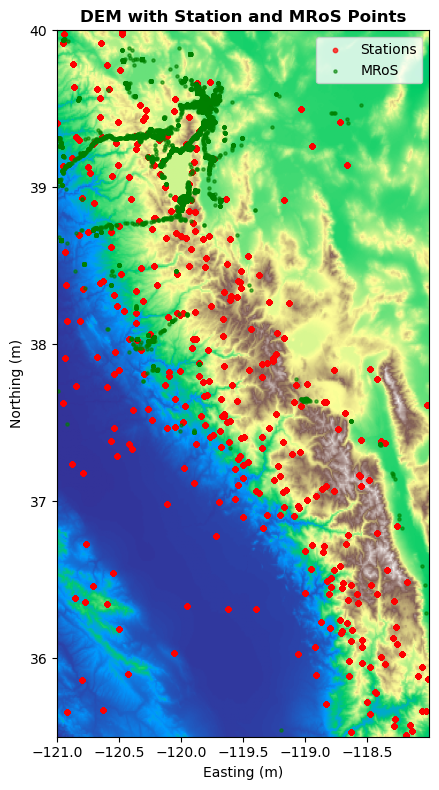

In [24]:
# ------------------ VISUALIZE: DEM + all data points --------------------
import matplotlib.pyplot as plt
from rasterio.plot import show

# Read DEM again for plotting
with rio.open(CONFIG["dem_path_km"]) as src:
    fig, ax = plt.subplots(figsize=(10, 8))
    show(src, ax=ax, cmap="terrain", title="DEM with Station and MRoS Points")

# Convert to GeoDataFrames for easy overlay
st_gdf = gpd.GeoDataFrame(st_hr, geometry=gpd.points_from_xy(st_hr["lon"], st_hr["lat"]), crs="EPSG:4326")
mros_gdf = gpd.GeoDataFrame(mros_hr, geometry=gpd.points_from_xy(mros_hr["lon"], mros_hr["lat"]), crs="EPSG:4326")

# Reproject to DEM CRS
st_gdf = st_gdf.to_crs(src.crs)
mros_gdf = mros_gdf.to_crs(src.crs)

# Plot each dataset
st_gdf.plot(ax=ax, markersize=10, color="red", label="Stations", alpha=0.7)
mros_gdf.plot(ax=ax, markersize=5, color="green", label="MRoS", alpha=0.6)

plt.legend()
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.tight_layout()
plt.show()


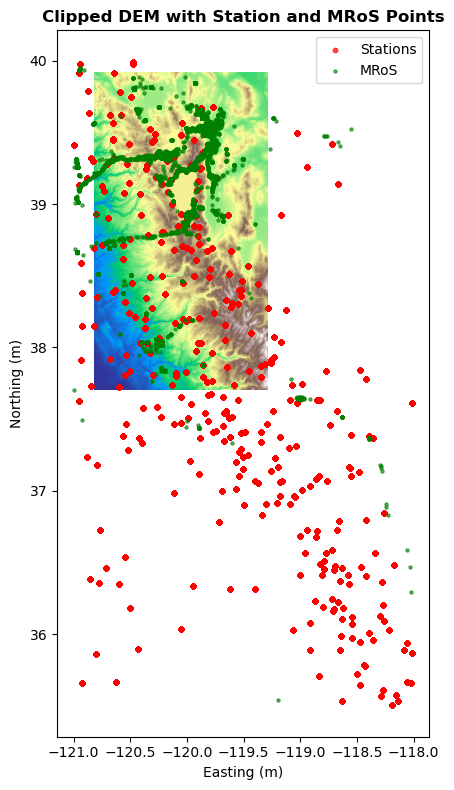

In [25]:
# Further clipping DEM 10/27/25
with rio.open(CONFIG["dem_path_km_clipped"]) as src:
    fig, ax = plt.subplots(figsize=(10, 8))
    show(src, ax=ax, cmap="terrain", title="Clipped DEM with Station and MRoS Points")

    # Plot each dataset
st_gdf.plot(ax=ax, markersize=10, color="red", label="Stations", alpha=0.7)
mros_gdf.plot(ax=ax, markersize=5, color="green", label="MRoS", alpha=0.6)

plt.legend()
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.tight_layout()
plt.show()